In [34]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.model_selection import cross_validate
from sklearn.linear_model import Lasso
from sklearn.linear_model import lasso_path
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict


df = pd.read_csv("Dataset.csv")

In [35]:
# Extract the target variable (the metric we are trying to predict)
y = df["Ladder score"]

# Create the feature matrix (predictors) by dropping columns we don't want the model to learn from.
# We drop the target variable itself, alongside identifying strings (Country Name/Code) and time markers.
X = df.drop(columns=[
    "Ladder score",
    "Country Name",
    "Country Code",
    "Time",
    "Time Code"
])

In [36]:
# Initialize the StandardScaler to normalize our features so they all have a mean of 0 and a standard deviation of 1.
# IMPORTANT: LASSO penalizes coefficients based on their size. If we don't scale the data, 
# variables with naturally large numbers (like GDP) will be unfairly penalized compared to smaller percentage metrics.
scaler = StandardScaler()

# Fit the scaler to our predictors and transform them into a scaled format
X_scaled = scaler.fit_transform(X)

In [37]:
# Initialize the LASSO model with built-in Cross-Validation.
# Setting cv=10 splits our data into 10 folds to automatically test and find the best penalty parameter (alpha).
lasso_cv = LassoCV(cv=10, max_iter=10000, random_state=42)

# Train the model on our scaled data. Behind the scenes, this tests dozens of alphas to find the one with the lowest error.
lasso_cv.fit(X_scaled, y)

print("Optimal lambda:", lasso_cv.alpha_)

Optimal lambda: 0.011825029260994218


In [38]:
# The model outputs a numpy array of coefficients. This line maps those numbers back to our original column names 
#so we can easily read which coefficient belongs to which predictor.
lasso_coef = pd.Series(lasso_cv.coef_, index=X.columns)

# LASSO performs automatic feature selection by shrinking useless variables to exactly 0.
lasso_coef.sort_values(ascending=False)

Gross domestic savings (% of GDP) [NY.GDS.TOTL.ZS]                                                                0.232111
Proportion of seats held by women in national parliaments (%) [SG.GEN.PARL.ZS]                                    0.189078
GDP per capita, PPP (constant 2021 international $) [NY.GDP.PCAP.PP.KD]                                           0.162393
Personal remittances, received (% of GDP) [BX.TRF.PWKR.DT.GD.ZS]                                                  0.156532
General government final consumption expenditure (% of GDP) [NE.CON.GOVT.ZS]                                      0.152461
Voice and Accountability: Estimate [VA.EST]                                                                       0.144924
Compulsory education, duration (years) [SE.COM.DURS]                                                              0.108377
Labor force, female (% of total labor force) [SL.TLF.TOTL.FE.ZS]                                                  0.067817
Labor force part

In [39]:
# Here, we filter the list to keep ONLY the predictors that survived the cut (non-zero coefficients).
selected_features = lasso_coef[lasso_coef != 0]

print(selected_features.sort_values(ascending=False))

Gross domestic savings (% of GDP) [NY.GDS.TOTL.ZS]                                                                0.232111
Proportion of seats held by women in national parliaments (%) [SG.GEN.PARL.ZS]                                    0.189078
GDP per capita, PPP (constant 2021 international $) [NY.GDP.PCAP.PP.KD]                                           0.162393
Personal remittances, received (% of GDP) [BX.TRF.PWKR.DT.GD.ZS]                                                  0.156532
General government final consumption expenditure (% of GDP) [NE.CON.GOVT.ZS]                                      0.152461
Voice and Accountability: Estimate [VA.EST]                                                                       0.144924
Compulsory education, duration (years) [SE.COM.DURS]                                                              0.108377
Labor force, female (% of total labor force) [SL.TLF.TOTL.FE.ZS]                                                  0.067817
Labor force part

In [40]:
summary = pd.DataFrame({
    "Zero Coefficient": [(lasso_coef == 0).sum()],
    "Non-zero Coefficient": [(lasso_coef != 0).sum()],
    "Total Variables": [len(lasso_coef)]
})

print(summary)

   Zero Coefficient  Non-zero Coefficient  Total Variables
0                13                    27               40


In [41]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.model_selection import cross_validate
import numpy as np

# 1. Create the pipeline to prevent data leakage
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=lasso_cv.alpha_, max_iter=10000, random_state=42))
])

# 2. Run cross-validation with all three scoring metrics
cv_results = cross_validate(
    lasso_pipeline, 
    X, 
    y, 
    cv=10, 
    scoring=('r2', 'neg_mean_absolute_error', 'neg_root_mean_squared_error')
)

# 3. Extract and print the mean of each metric across the 10 folds
# (We use a negative sign to flip scikit-learn's negative errors back to positive)
print("--- Model Evaluation Results ---")
print(f"Mean R^2:   {np.mean(cv_results['test_r2']):.4f}")
print(f"Mean MAE:   {-np.mean(cv_results['test_neg_mean_absolute_error']):.4f}")
print(f"Mean RMSE:  {-np.mean(cv_results['test_neg_root_mean_squared_error']):.4f}")

--- Model Evaluation Results ---
Mean R^2:   0.7235
Mean MAE:   0.4350
Mean RMSE:  0.5675


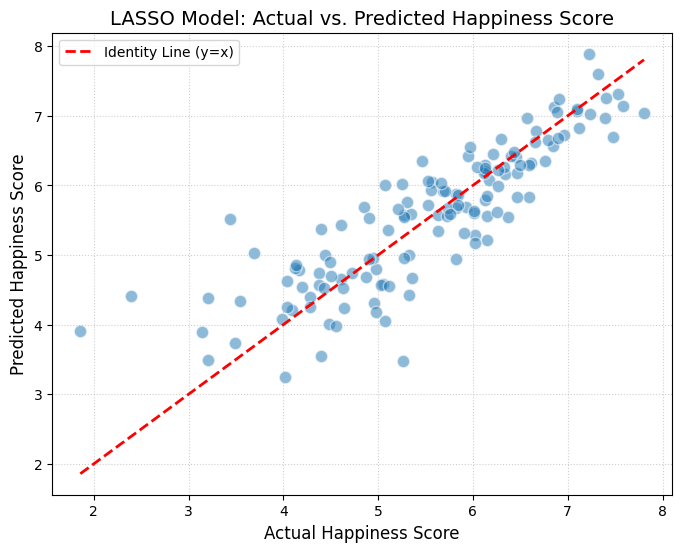

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Plotting the dots with slight transparency (alpha) to show density
plt.scatter(y, y_pred_cv, alpha=0.5, color='#1f77b4', edgecolors='white', s=80)

# The 45-degree reference line
line_coords = [y.min(), y.max()]
plt.plot(line_coords, line_coords, color='red', linestyle='--', linewidth=2, label='Identity Line (y=x)')

plt.title('LASSO Model: Actual vs. Predicted Happiness Score', fontsize=14)
plt.xlabel('Actual Happiness Score', fontsize=12)
plt.ylabel('Predicted Happiness Score', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [46]:
# Extract the names of the 27 features LASSO selected
remaining_features = selected_features.index.tolist()

# Isolate these features from your original (unscaled) X dataframe
X_selected = X[remaining_features]

# Create the Binary Target (1 = Above Median Happiness, 0 = Below Median)
median_score = y.median()
y_binary = (y > median_score).astype(int)

# Scale the selected features (Crucial for VIF and Logistic Regression)
X_selected_scaled = pd.DataFrame(scaler.fit_transform(X_selected), columns=X_selected.columns)

In [47]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df["Feature"] = data.columns
    vif_list = []
    
    for col in data.columns:
        X_vif = data.drop(columns=[col])
        y_vif = data[col]
        
        # Fit a simple linear regression
        model = LinearRegression().fit(X_vif, y_vif)
        r_sq = model.score(X_vif, y_vif)
        
        # Calculate VIF
        if r_sq == 1.0:
            vif = np.inf
        else:
            vif = 1 / (1 - r_sq)
            
        vif_list.append(vif)
        
    vif_df["VIF"] = vif_list
    return vif_df

# VIF filtering loop
vif_threshold = 5.0
features_to_keep = X_selected_scaled.columns.tolist()

while True:
    vif_data = calculate_vif(X_selected_scaled[features_to_keep])
    max_vif = vif_data['VIF'].max()
    
    if max_vif > vif_threshold:
        feature_to_drop = vif_data.loc[vif_data['VIF'].idxmax(), 'Feature']
        print(f"Dropping: '{feature_to_drop}' (VIF: {max_vif:.2f})")
        features_to_keep.remove(feature_to_drop)
    else:
        break

print(f"\nSuccess! {len(features_to_keep)} features remain after VIF filtering.")
X_vif_filtered = X_selected_scaled[features_to_keep]

Dropping: 'Employment in agriculture (% of total employment) (modeled ILO estimate) [SL.AGR.EMPL.ZS]' (VIF: 16.28)
Dropping: 'Vulnerable employment, total (% of total employment) (modeled ILO estimate) [SL.EMP.VULN.ZS]' (VIF: 9.11)
Dropping: 'GDP per capita, PPP (constant 2021 international $) [NY.GDP.PCAP.PP.KD]' (VIF: 6.77)
Dropping: 'Access to electricity (% of population) [EG.ELC.ACCS.ZS]' (VIF: 5.88)

Success! 23 features remain after VIF filtering.


In [48]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
log_reg = LogisticRegression(random_state=42, penalty='l2')

# Setup RFE to find the top 10 features
rfe = RFE(estimator=log_reg, n_features_to_select=10, step=1)
rfe.fit(X_vif_filtered, y_binary)

# Extract the final 10 feature names
final_features = np.array(features_to_keep)[rfe.support_]
print("Top 10 Drivers of Happiness Selected by RFE:")
for f in final_features:
    print(f"- {f}")

Top 10 Drivers of Happiness Selected by RFE:
- GDP growth (annual %) [NY.GDP.MKTP.KD.ZG]
- General government final consumption expenditure (% of GDP) [NE.CON.GOVT.ZS]
- Labor force participation rate, total (% of total population ages 15+) (modeled ILO estimate) [SL.TLF.CACT.ZS]
- Labor force, female (% of total labor force) [SL.TLF.TOTL.FE.ZS]
- Military expenditure (% of GDP) [MS.MIL.XPND.GD.ZS]
- Mortality rate, infant (per 1,000 live births) [SP.DYN.IMRT.IN]
- Personal remittances, received (% of GDP) [BX.TRF.PWKR.DT.GD.ZS]
- Unemployment, total (% of total labor force) (modeled ILO estimate) [SL.UEM.TOTL.ZS]
- Prevalence of undernourishment (% of population) [SN.ITK.DEFC.ZS]
- Voice and Accountability: Estimate [VA.EST]


In [49]:
# Fit the final Logistic Regression model
X_final = X_vif_filtered[final_features]
final_model = LogisticRegression(random_state=42)
final_model.fit(X_final, y_binary)

# Extract Coefficients and convert to Odds Ratios
insights_df = pd.DataFrame({
    'Predictor': final_features,
    'Coefficient': final_model.coef_[0],
    'Odds_Ratio': np.exp(final_model.coef_[0])
})

# Sort by Odds Ratio
insights_df = insights_df.sort_values(by='Odds_Ratio', ascending=False).reset_index(drop=True)

print("\n--- FINAL MODEL INSIGHTS ---")
display(insights_df)


--- FINAL MODEL INSIGHTS ---


,Predictor,Coefficient,Odds_Ratio
0,General government final consumption expenditu...,1.316090,3.728812
1,Voice and Accountability: Estimate [VA.EST],1.206490,3.341736
2,"Labor force participation rate, total (% of to...",1.108202,3.028909
3,GDP growth (annual %) [NY.GDP.MKTP.KD.ZG],0.526807,1.693516
4,"Personal remittances, received (% of GDP) [BX....",0.434897,1.544804
5,Prevalence of undernourishment (% of populatio...,-0.615665,0.540282
6,"Labor force, female (% of total labor force) [...",-0.667584,0.512946
7,Military expenditure (% of GDP) [MS.MIL.XPND.G...,-1.052417,0.349093
8,"Unemployment, total (% of total labor force) (...",-1.181716,0.306752
9,"Mortality rate, infant (per 1,000 live births)...",-2.305769,0.099682


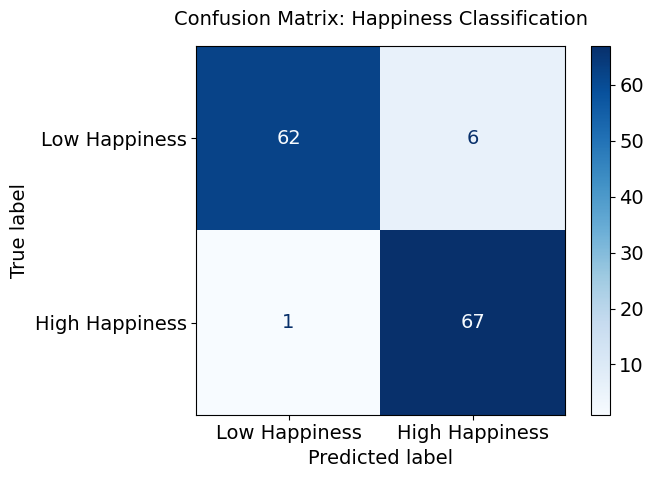

In [72]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, classification_report

# 1. Generate predictions and probabilities from your final model
y_pred = final_model.predict(X_final)
y_probs = final_model.predict_proba(X_final)[:, 1]

# Set global font sizes for better visibility in LaTeX
plt.rcParams.update({'font.size': 14}) # Base font size
plt.rcParams.update({'axes.labelsize': 14}) # Axis labels (True label, Predicted label)
plt.rcParams.update({'axes.titlesize': 14}) # Title size

# ==========================================
# 2. Plot the Confusion Matrix
# ==========================================
cm = confusion_matrix(y_binary, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low Happiness', 'High Happiness'])

# Slightly increased width from (4,4) to (5,4) gives the colorbar more room to breathe
fig, ax = plt.subplots(figsize=(7, 5)) 

disp.plot(cmap='Blues', ax=ax)

# Added 'pad=15' to push the title slightly higher above the plot area
plt.title("Confusion Matrix: Happiness Classification", pad=15) 

# This is the magic function that prevents elements from overlapping
plt.tight_layout() 

# Save the plot
plt.savefig('Confusion Matrix.png', dpi=300, bbox_inches='tight')
plt.show()



/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


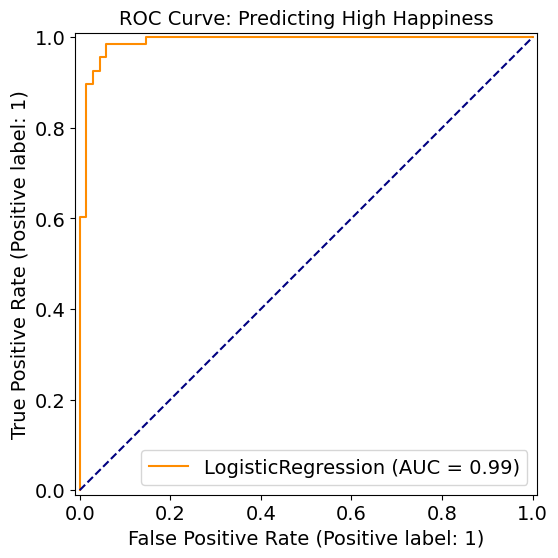

In [71]:
# ==========================================
# 3. Plot the ROC Curve
# ==========================================
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(final_model, X_final, y_binary, ax=ax, color='darkorange')

# Plot the 'random guessing' baseline
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.title("ROC Curve: Predicting High Happiness")

# Save the plot
plt.savefig('ROC Curve.png', dpi=300, bbox_inches='tight')

plt.show()

In [54]:
# ==========================================
# 4. Print the Classification Report
# ==========================================
print("\n--- CLASSIFICATION REPORT ---")
report = classification_report(y_binary, y_pred, target_names=['Low Happiness', 'High Happiness'])
print(report)


--- CLASSIFICATION REPORT ---
                precision    recall  f1-score   support

 Low Happiness       0.98      0.91      0.95        68
High Happiness       0.92      0.99      0.95        68

      accuracy                           0.95       136
     macro avg       0.95      0.95      0.95       136
  weighted avg       0.95      0.95      0.95       136

